In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from keras.layers import (
    Conv1D,
    MaxPooling1D,
    Dense,
    BatchNormalization,
    GlobalAveragePooling1D,
    Dropout,
    Add,
    Input
)

from keras.models import Model

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    matthews_corrcoef
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/ecg_datasets/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/ecg_datasets/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


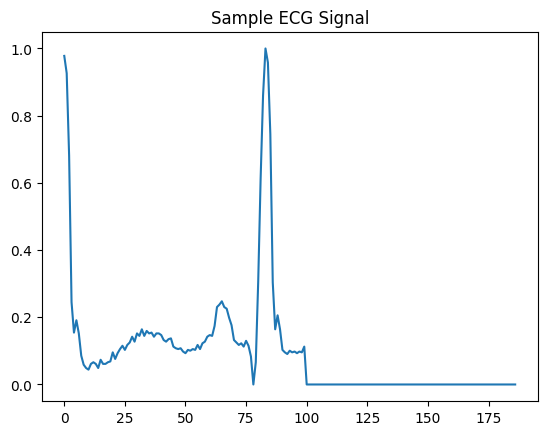

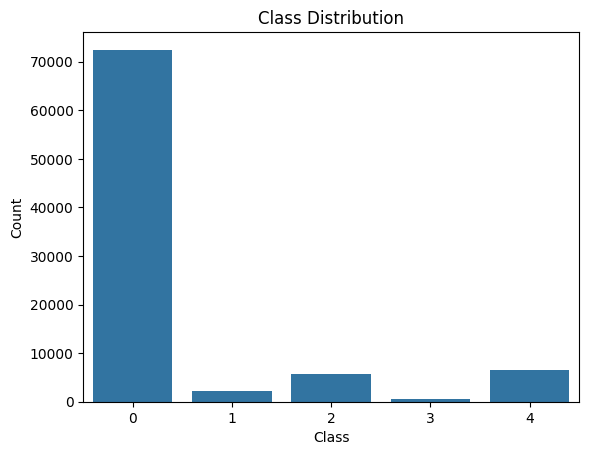

In [5]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()

sns.barplot(
    x=[0,1,2,3,4],
    y=counts.values
)

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

In [6]:
print("Train Missing:", train.isna().sum().sum())
print("Test Missing :", test.isna().sum().sum())

Train Missing: 0
Test Missing : 0


In [7]:
X_train = train.iloc[:, :-1].values
y_train = train.iloc[:, -1].values

X_test = test.iloc[:, :-1].values
y_test = test.iloc[:, -1].values

X_test = X_test.reshape(-1, 187, 1)

y_test_cat = to_categorical(y_test, 5)

In [8]:
def resnet_block(x, filters, stride=1):

    shortcut = x

    x = Conv1D(
        filters,
        3,
        strides=stride,
        padding='same'
    )(x)

    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = Conv1D(
        filters,
        3,
        padding='same'
    )(x)

    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:

        shortcut = Conv1D(
            filters,
            1,
            strides=stride,
            padding='same'
        )(shortcut)

        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])

    x = tf.keras.layers.Activation('relu')(x)

    return x

In [9]:
def dice_loss(y_true, y_pred, smooth=1e-6):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    y_pred = tf.cast(
        y_pred,
        tf.float32
    )

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=1
    )

    denominator = (
        tf.reduce_sum(y_true, axis=1)
        +
        tf.reduce_sum(y_pred, axis=1)
    )

    dice = (
        2.0 * intersection + smooth
    ) / (
        denominator + smooth
    )

    return 1.0 - tf.reduce_mean(dice)

In [12]:
def resnet_ecg():

    inputs = Input(
        shape=(187,1)
    )

    x = Conv1D(
        32,
        3,
        activation='relu'
    )(inputs)

    x = BatchNormalization()(x)

    x = resnet_block(x,64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,128)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(
        128,
        activation='relu'
    )(x)

    x = Dropout(0.5)(x)

    outputs = Dense(
        5,
        activation='softmax'
    )(x)

    model = Model(
        inputs,
        outputs
    )

    model.compile(
    optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0005),
    loss=dice_loss,
    metrics=['accuracy']
)

    return model

In [13]:
kfold = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(
    kfold.split(X_train, y_train)
):

    print(f"\nFold {fold+1}")

    X_tr = X_train[train_idx]
    y_tr = y_train[train_idx]

    X_va = X_train[val_idx]
    y_va = y_train[val_idx]

    smote = SMOTE(
        random_state=42
    )

    X_tr, y_tr = smote.fit_resample(
        X_tr,
        y_tr
    )

    X_tr = X_tr.reshape(-1,187,1)
    X_va = X_va.reshape(-1,187,1)

    y_tr = to_categorical(y_tr,5)
    y_va = to_categorical(y_va,5)

    model = resnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(
        X_va,
        y_va,
        verbose=0
    )

    print(
        f"Fold {fold+1} Accuracy: {acc:.4f}"
    )

    cv_accuracies.append(acc)

print("\nCV Accuracies:", cv_accuracies)
print("Mean CV:", np.mean(cv_accuracies))
print("Std CV :", np.std(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 51s 10ms/step - accuracy: 0.9042 - loss: 0.1014
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9428 - loss: 0.0587
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.9566 - loss: 0.0442
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9662 - loss: 0.0343
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9706 - loss: 0.0299
Fold 1 Accuracy: 0.9606

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 51s 10ms/step - accuracy: 0.9054 - loss: 0.1004
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9466 - loss: 0.0551
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9603 - loss: 0.0406
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9673 - loss: 0.0334
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9707 - loss: 0.0298
Fold 2 Accuracy: 0.9678

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 52s 1

In [14]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

smote = SMOTE(
    random_state=42
)

X_train_final, y_train_final = smote.fit_resample(
    X_train_final,
    y_train_final
)

X_train_final = X_train_final.reshape(
    -1,
    187,
    1
)

X_val_final = X_val_final.reshape(
    -1,
    187,
    1
)

y_train_final = to_categorical(
    y_train_final,
    5
)

y_val_final = to_categorical(
    y_val_final,
    5
)

In [17]:
model = resnet_ecg()

#early_stop = EarlyStopping(
 #   monitor='val_loss',
  #  patience=3,
   # restore_best_weights=True
#)

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(
        X_val_final,
        y_val_final
    ),
    epochs=10,
    batch_size=64,
    #callbacks=[early_stop]
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 64s 11ms/step - accuracy: 0.9082 - loss: 0.0970 - val_accuracy: 0.6563 - val_loss: 0.3477
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - accuracy: 0.9514 - loss: 0.0498 - val_accuracy: 0.9548 - val_loss: 0.0459
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - accuracy: 0.9616 - loss: 0.0390 - val_accuracy: 0.9450 - val_loss: 0.0551
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9692 - loss: 0.0313 - val_accuracy: 0.9452 - val_loss: 0.0555
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9724 - loss: 0.0280 - val_accuracy: 0.9587 - val_loss: 0.0420
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - accuracy: 0.9758 - loss: 0.0245 - val_accuracy: 0.9342 - val_loss: 0.0657
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9774 - loss: 0.0229 - val_accuracy: 0.9123 - val_loss: 0.0882
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9798 - loss: 

In [19]:
y_val_pred = np.argmax(
    model.predict(X_val_final),
    axis=1
)

y_val_true = np.argmax(
    y_val_final,
    axis=1
)

mcc_val = matthews_corrcoef(
    y_val_true,
    y_val_pred
)

print(
    "Validation MCC:",
    mcc_val
)

548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Validation MCC: 0.7988692434337332


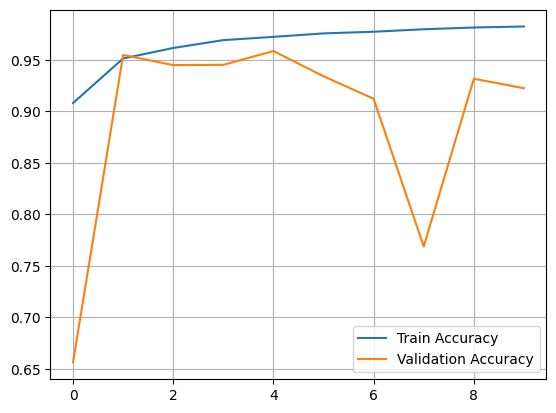

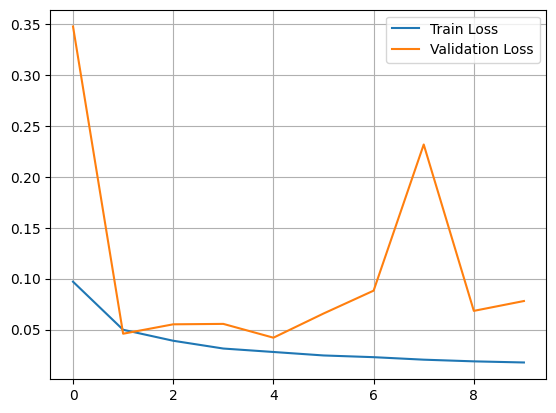

In [20]:
plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.legend()
plt.grid()
plt.show()


plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()
plt.grid()
plt.show()

In [21]:
train_loss, train_acc = model.evaluate(
    X_train_final,
    y_train_final,
    verbose=0
)

val_loss, val_acc = model.evaluate(
    X_val_final,
    y_val_final,
    verbose=0
)

test_loss, test_acc = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Train Accuracy :", train_acc)
print("Validation Accuracy :", val_acc)
print("Test Accuracy :", test_acc)

Train Accuracy : 0.9791365265846252
Validation Accuracy : 0.9225629568099976
Test Accuracy : 0.9204275608062744


In [22]:
y_test_pred = np.argmax(
    model.predict(X_test),
    axis=1
)

print(
    classification_report(
        y_test,
        y_test_pred
    )
)

685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.91      0.95     18118
         1.0       0.27      0.87      0.41       556
         2.0       0.94      0.94      0.94      1448
         3.0       0.59      0.86      0.70       162
         4.0       0.93      1.00      0.96      1608

    accuracy                           0.92     21892
   macro avg       0.74      0.92      0.79     21892
weighted avg       0.96      0.92      0.94     21892



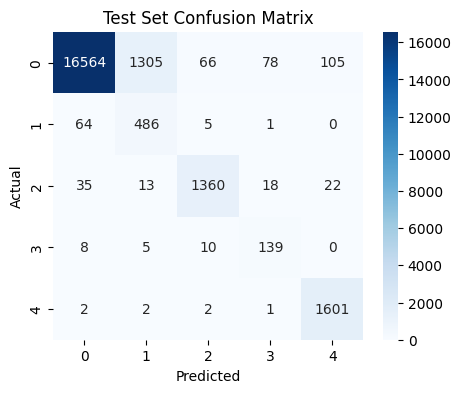

In [23]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Set Confusion Matrix")

plt.show()